In [1]:
import numpy as np
import matplotlib.pyplot as plt
#严格解法
def calculate_strict_probabilities_yan(u=1, Z=3, E_set=None):
    c_val = u/1000
    
    if E_set is None:
        E_set = np.linspace(c_val, 1.5*c_val, 1000)
    d_set = []
    c_set = []
    b_set = []
    a_set = []
    z_set = []
    H = 2*Z * (u)**0.5  

    for E in E_set:
        u0 = (0.5 * (1 + (E**2 - c_val**2)**0.5 / E))**0.5
        v0 = (0.5 * (1 - (E**2 - c_val**2)**0.5 / E))**0.5
        q_e = (u + E)**0.5
        q_h = (u - E)**0.5
        k_e = (u + (E**2 - c_val**2)**0.5)**0.5
        k_h = (u - (E**2 - c_val**2)**0.5)**0.5

        denominator = (u0**2 * (k_e + q_e - H/(1j)) * (k_h + q_h + H/(1j)) + 
                      v0**2 * (q_e - k_h - H/(1j)) * (k_e - q_h - H/(1j)))
        
        d = 2 * q_e * v0 * (k_e - q_h - H/(1j)) / denominator
        cc = d * u0 * (k_h + q_h + H/(1j)) / (v0 * k_e - v0 * q_h - v0 * H/(1j))
        b = cc * u0 + d * v0 - 1
        a = cc * v0 + d * u0
        
        # 计算概率
        d1 = abs(d)**2 * (abs(u0)**2 - abs(v0)**2) * k_h / q_e
        c1 = abs(cc)**2 * (abs(u0)**2 - abs(v0)**2) * k_e / q_e
        b1 = abs(b)**2 * 1 * q_e / q_e  
        a1 = abs(a)**2 * 1 * q_h / q_e
        
        a_set.append(a1)
        b_set.append(b1)
        c_set.append(c1)
        d_set.append(d1)
        z_set.append(a1 + b1 + c1 + d1)
    
    return a_set, b_set, c_set, d_set

def calculate_strict_probabilities_yan1(u=1, Z=3, E_set=None):
    c_val = u/1000
    if E_set is None:
        E_set = np.linspace(c_val, 1.5*c_val, 1000)
    d_set = []
    c_set = []
    b_set = []
    a_set = []
    z_set = []
    H = 2*Z * (u)**0.5  

    for E in E_set:
        u0 = (0.5 * (1 + 1j*(-E**2 + c_val**2)**0.5 / E))**0.5
        v0 = (0.5 * (1 - 1j*(-E**2 + c_val**2)**0.5 / E))**0.5
        q_e = (u + E)**0.5
        q_h = (u - E)**0.5
        k_e = (u + 1j*(-E**2 + c_val**2)**0.5)**0.5
        k_h = (u - 1j*(-E**2 + c_val**2)**0.5)**0.5

        denominator = (u0**2 * (k_e + q_e - H/(1j)) * (k_h + q_h + H/(1j)) + 
                      v0**2 * (q_e - k_h - H/(1j)) * (k_e - q_h - H/(1j)))
        
        d = 2 * q_e * v0 * (k_e - q_h - H/(1j)) / denominator
        cc = d * u0 * (k_h + q_h + H/(1j)) / (v0 * k_e - v0 * q_h - v0 * H/(1j))
        b = cc * u0 + d * v0 - 1
        a = cc * v0 + d * u0
        
        # 计算概率
        d1 = abs(d)**2 * (abs(u0)**2 - abs(v0)**2) * k_h / q_e
        c1 = abs(cc)**2 * (abs(u0)**2 - abs(v0)**2) * k_e / q_e
        b1 = abs(b)**2 * 1 * q_e / q_e  
        a1 = abs(a)**2 * 1 * q_h / q_e
        
        a_set.append(a1)
        b_set.append(b1)
        c_set.append(c1)
        d_set.append(d1)
        z_set.append(a1 + b1 + c1 + d1)
    
    return a_set, b_set, c_set, d_set


c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


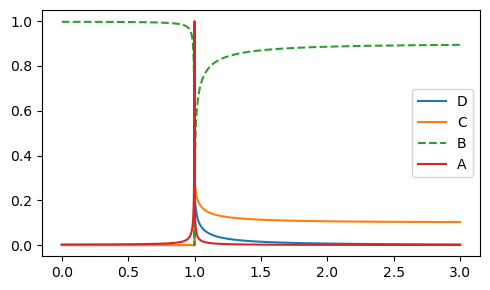

In [4]:
if __name__ == "__main__":
    u = 1000
    Z = 3
    c_val = u/1000
   
    E_set1 = np.linspace(c_val, 3*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1 = calculate_strict_probabilities_yan(u, Z, E_set1)
    
  
    E_set2 = np.linspace(0.0001*c_val, c_val, 1000)
    a_set2, b_set2, c_set2, d_set2 = calculate_strict_probabilities_yan1(u, Z, E_set2)
    
    E_set_combined = np.concatenate([E_set2, E_set1])
    a_set_combined = np.concatenate([a_set2, a_set1])
    b_set_combined = np.concatenate([b_set2, b_set1])
    c_set_combined = np.concatenate([c_set2, c_set1])
    d_set_combined = np.concatenate([d_set2, d_set1])
    
    plt.figure(figsize=(5, 3))
    plt.plot(E_set_combined, d_set_combined, label='D')  
    plt.plot(E_set_combined, c_set_combined, label='C')
    plt.plot(E_set_combined, b_set_combined, label='B', linestyle='--')
    plt.plot(E_set_combined, a_set_combined, label='A')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
#近似
def calculate_probabilities(u, Z, E_set):
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    for E in E_set:
        H = 2 * (u**0.5) * Z
        v0 = (0.5 * (1 - (E**2 - (u/1000)**2)**0.5 / E))**0.5
        u0 = (0.5 * (1 + (E**2 - (u/1000)**2)**0.5 / E))**0.5
        kf = (u)**0.5
        lada = (u0**2 + (u0**2 - v0**2) * (Z**2))
        
        d = 1j * v0 * Z / lada
        cc = u0 * (1 - 1j * Z) / lada
        b = -(u0**2 - v0**2) * (1j * Z + Z**2) / lada
        a = u0 * v0 / lada
        
        d1 = abs(d)**2 * (abs(u0)**2 - abs(v0)**2)
        c1 = abs(cc)**2 * (abs(u0)**2 - abs(v0)**2)
        b1 = abs(b)**2 
        a1 = abs(a)**2 
        a_set.append(a1)
        b_set.append(b1)
        c_set.append(c1)
        d_set.append(d1)
    
    return a_set, b_set, c_set, d_set
def calculate_probabilities1(u, Z, E_set):
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    for E in E_set:
        H = 2 * (u**0.5) * Z
        v0 = (0.5 * (1 - 1j*(-E**2 + (u/1000)**2)**0.5 / E))**0.5
        u0 = (0.5 * (1 + 1j*(-E**2 + (u/1000)**2)**0.5 / E))**0.5
        kf = (u)**0.5
        lada = (u0**2 + (u0**2 - v0**2) * (Z**2))
        
        d = 1j * v0 * Z / lada
        cc = u0 * (1 - 1j * Z) / lada
        b = -(u0**2 - v0**2) * (1j * Z + Z**2) / lada
        a = u0 * v0 / lada
        
        d1 = abs(d)**2 * (abs(u0)**2 - abs(v0)**2)
        c1 = abs(cc)**2 * (abs(u0)**2 - abs(v0)**2)
        b1 = abs(b)**2 
        a1 = abs(a)**2 
        a_set.append(a1)
        b_set.append(b1)
        c_set.append(c1)
        d_set.append(d1)
    
    return a_set, b_set, c_set, d_set

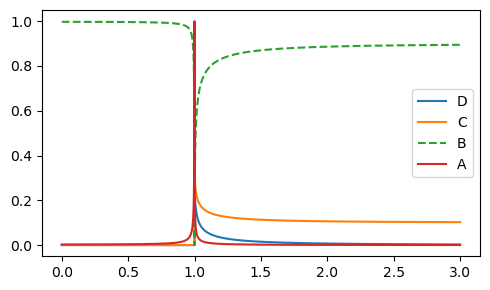

In [12]:
if __name__ == "__main__":
    u = 1000
    Z = 3
    c_val = u/1000
   
    E_set1 = np.linspace(c_val, 3*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1 = calculate_probabilities(u, Z, E_set1)
    
  
    E_set2 = np.linspace(0.0001*c_val, c_val, 1000)
    a_set2, b_set2, c_set2, d_set2 = calculate_probabilities1(u, Z, E_set2)
    
    E_set_combined = np.concatenate([E_set2, E_set1])
    a_set_combined = np.concatenate([a_set2, a_set1])
    b_set_combined = np.concatenate([b_set2, b_set1])
    c_set_combined = np.concatenate([c_set2, c_set1])
    d_set_combined = np.concatenate([d_set2, d_set1])
    
    plt.figure(figsize=(5, 3))
    plt.plot(E_set_combined, d_set_combined, label='D')  
    plt.plot(E_set_combined, c_set_combined, label='C')
    plt.plot(E_set_combined, b_set_combined, label='B', linestyle='--')
    plt.plot(E_set_combined, a_set_combined, label='A')
    plt.legend()
    plt.tight_layout()
    plt.show()